<a href="https://colab.research.google.com/github/Hemanthhhhhh-HK/invoice_fraud_detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/fraud_dirty.csv')


In [2]:
df.isnull().sum()

,0
Invoice_ID,0
Vendor_ID,59
Invoice_Date,33
Due_Date,0
Invoice_Amount,297
Tax_Amount,357
Total_Amount,0
Payment_Status,1038
Payment_Date,0
Processing_Days,249


In [3]:
df = df.drop_duplicates(subset="Invoice_ID",keep="first")

In [4]:
fraud_map = {
    # Positive (fraudulent)
    "1": 1, "true": 1, "yes": 1, "y": 1, "high": 1, "risk": 1,
    # Negative (legitimate)
    "0": 0, "false": 0, "no": 0, "n": 0, "low": 0, "safe": 0,
}
df["Fraud_Flag"] = (
    df["Fraud_Flag"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(fraud_map)
)

In [5]:
df = df.dropna(subset=["Fraud_Flag"])
df["Fraud_Flag"] = df["Fraud_Flag"].astype(int)

In [6]:
payment_map = {
    "approved": "Approved",
    "ok": "Approved",
    "1": "Approved",
    "y": "Approved",
    "paid": "Paid",
    "pending": "Pending",
    "rejected": "Rejected",
    "fail": "Rejected",
    "0": "Rejected",
    "n": "Rejected",
}
df["Payment_Status"] = (
    df["Payment_Status"]
    .astype(str).str.strip().str.lower()
    .map(payment_map)
)
mode_status = df["Payment_Status"].mode()[0]
df["Payment_Status"] = df["Payment_Status"].fillna(mode_status)

In [7]:
transactiontype_map = {
    "invoice": "Invoice",
    "credit": "Credit",
    "credit note": "Credit Note",
    "debit note": "Debit Note",
    "debit": "Debit Note",
    "adjustment": "Adjustment",
    "adj": "Adjustment",
}
df["Transaction_Type"] = (
    df["Transaction_Type"]
    .astype(str).str.strip().str.lower()
    .map(transactiontype_map)
)
mode_txtype = df["Transaction_Type"].mode()[0]
df["Transaction_Type"] = df["Transaction_Type"].fillna(mode_txtype)

In [8]:
name_map = {
    "jane":         "Jane Doe",
    "jane doe":     "Jane Doe",
    "john":         "John Smith",
    "john smith":   "John Smith",
    "tom brown":    "Tom Brown",
    "tom":          "Tom Brown",
    "mike johnson": "Mike Johnson",
    "mike":         "Mike Johnson",
    "sarah williams": "Sarah Williams",
    "sarah":        "Sarah Williams",
}
df["Approved_By"] = (
    df["Approved_By"]
    .astype(str).str.strip().str.lower()
    .map(name_map)
)
mode_approver = df["Approved_By"].mode()[0]
df["Approved_By"] = df["Approved_By"].fillna(mode_approver)

In [9]:
date_cols = ["Invoice_Date", "Due_Date", "Payment_Date"]
# Process date columns only if they exist
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Fill missing Invoice_Date only if it exists and has NaNs
if 'Invoice_Date' in df.columns:
    # Only calculate median if there are non-null dates
    if not df['Invoice_Date'].dropna().empty:
        median_invoice_date = df["Invoice_Date"].dropna().sort_values().iloc[len(df["Invoice_Date"].dropna()) // 2]
        df["Invoice_Date"] = df["Invoice_Date"].fillna(median_invoice_date)
    else:
        # Handle case where all Invoice_Date are NaN after coercion
        # For simplicity, if all are NaN, we might choose to drop it or fill with a default
        # For now, let's assume there will be some valid dates.
        print("Warning: All Invoice_Date entries are NaT after conversion. Cannot calculate median.")

# Engineer Credit_Period_Days only if required columns exist
if 'Due_Date' in df.columns and 'Invoice_Date' in df.columns:
    df["Credit_Period_Days"] = (df["Due_Date"] - df["Invoice_Date"]).dt.days

# Engineer Is_Late_Payment only if required columns exist
if 'Payment_Date' in df.columns and 'Due_Date' in df.columns:
    df["Is_Late_Payment"] = (df["Payment_Date"] > df["Due_Date"]).astype(int)

# Drop raw date columns only if they still exist
# Filter out columns that are already dropped to avoid KeyError
existing_date_cols_to_drop = [col for col in date_cols if col in df.columns]
if existing_date_cols_to_drop:
    df = df.drop(columns=existing_date_cols_to_drop)

In [10]:
df["Invoice_Amount"] = pd.to_numeric(df["Invoice_Amount"], errors="coerce")
Q1 = df["Invoice_Amount"].quantile(0.25)
Q3 = df["Invoice_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_fence = max(0, Q1 - 1.5 * IQR)   # invoices can't be negative
upper_fence = Q3 + 1.5 * IQR

print(f"\nInvoice_Amount fences → lower: {lower_fence:.0f}, upper: {upper_fence:.0f}")
df["Invoice_Amount"] = df["Invoice_Amount"].clip(lower=lower_fence, upper=upper_fence)


Invoice_Amount fences → lower: 0, upper: 152304


In [11]:
num_cols_with_na = ["Invoice_Amount", "Tax_Amount", "Processing_Days", "Vendor_Reliability_Score"]
for col in num_cols_with_na:
    df[col] = pd.to_numeric(df[col], errors="coerce") # Convert column to numeric, coercing errors to NaN
    median_val = df[col].median()
    n_filled = df[col].isna().sum()
    df[col] = df[col].fillna(median_val)
    if n_filled > 0:
        print(f"Filled {n_filled} NaNs in {col} with median={median_val:.2f}")

Filled 338 NaNs in Invoice_Amount with median=50334.00
Filled 340 NaNs in Tax_Amount with median=5118.33
Filled 215 NaNs in Processing_Days with median=15.00
Filled 217 NaNs in Vendor_Reliability_Score with median=5.00


In [12]:
cat_cols = ["Vendor_ID"]
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

In [13]:
low_card_cols = ["Payment_Status", "Transaction_Type"]
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# Label-encode Vendor_ID and Approved_By (high cardinality)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ["Vendor_ID", "Approved_By"]:
    df[col] = le.fit_transform(df[col].astype(str))


In [14]:
df = df.drop(columns=["Invoice_ID"])

In [15]:
df.isnull().sum()

,0
Vendor_ID,0
Invoice_Amount,0
Tax_Amount,0
Total_Amount,0
Processing_Days,0
Approval_Level,0
Approved_By,0
Vendor_Reliability_Score,0
Invoice_Frequency,0
Avg_Invoice_Amount,0


In [16]:
df.to_csv("/content/final_cleaned_data.csv",index=False)

In [17]:
# Create a new column 'Risk_Level'
df['Risk_Level'] = -1 # Initialize with a placeholder

# Step 1: Assign Low Risk (0) to non-fraudulent transactions
df.loc[df['Fraud_Flag'] == 0, 'Risk_Level'] = 0

# Step 2: For fraudulent transactions (Fraud_Flag == 1)
fraudulent_transactions = df[df['Fraud_Flag'] == 1]

# Calculate the 75th percentile of Total_Amount for fraudulent transactions
total_amount_q75_fraud = fraudulent_transactions['Total_Amount'].quantile(0.75)
print(f"75th percentile of Total_Amount for fraudulent transactions: {total_amount_q75_fraud:.2f}")

# Assign High Risk (2) to fraudulent transactions with Total_Amount above Q3
df.loc[
    (df['Fraud_Flag'] == 1) & (df['Total_Amount'] > total_amount_q75_fraud),
    'Risk_Level'
] = 2

# Assign Medium Risk (1) to remaining fraudulent transactions (those not assigned High Risk yet)
df.loc[
    (df['Fraud_Flag'] == 1) & (df['Risk_Level'] == -1),
    'Risk_Level'
] = 1

# Display the value counts for the new Risk_Level column
print("\nDistribution of Risk_Level:")
print(df['Risk_Level'].value_counts())

# Display a sample of the DataFrame with Fraud_Flag, Total_Amount, and Risk_Level
print("\nSample of DataFrame with Fraud_Flag, Total_Amount, and Risk_Level:")
display(df[['Fraud_Flag', 'Total_Amount', 'Risk_Level']].sample(5))

75th percentile of Total_Amount for fraudulent transactions: 83174.80

Distribution of Risk_Level:
Risk_Level
0    4270
1    3229
2    1077
Name: count, dtype: int64

Sample of DataFrame with Fraud_Flag, Total_Amount, and Risk_Level:


,Fraud_Flag,Total_Amount,Risk_Level
820,1,3794.54,1
5463,0,70148.27,0
7204,1,51976.74,1
3754,0,54019.35,0
7040,1,24794.35,1


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8576 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Vendor_ID                     8576 non-null   int64  
 1   Invoice_Amount                8576 non-null   float64
 2   Tax_Amount                    8576 non-null   float64
 3   Total_Amount                  8576 non-null   float64
 4   Processing_Days               8576 non-null   float64
 5   Approval_Level                8576 non-null   int64  
 6   Approved_By                   8576 non-null   int64  
 7   Vendor_Reliability_Score      8576 non-null   float64
 8   Invoice_Frequency             8576 non-null   int64  
 9   Avg_Invoice_Amount            8576 non-null   int64  
 10  Deviation_From_Avg            8576 non-null   float64
 11  Fraud_Flag                    8576 non-null   int64  
 12  Credit_Period_Days            8576 non-null   int64  
 13  Is_Late_

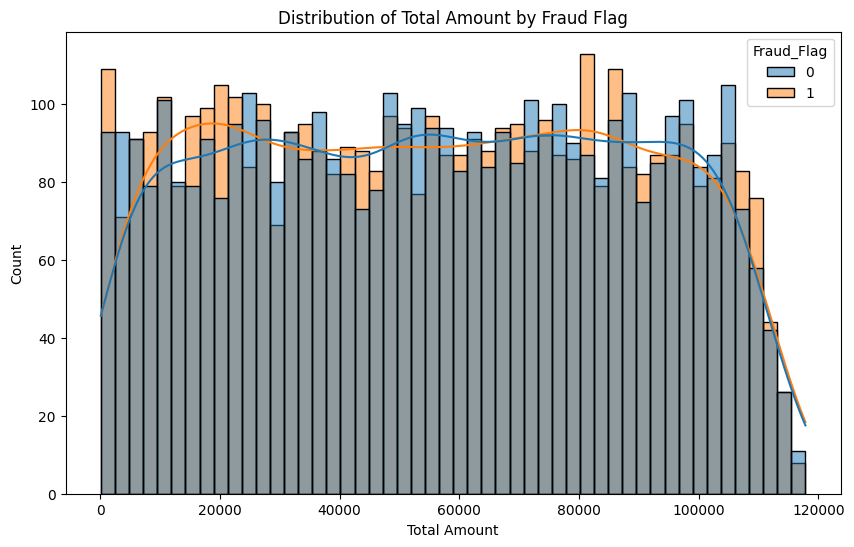

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Total_Amount', hue='Fraud_Flag', kde=True, bins=50)
plt.title('Distribution of Total Amount by Fraud Flag')
plt.xlabel('Total Amount')
plt.ylabel('Count')
plt.show()

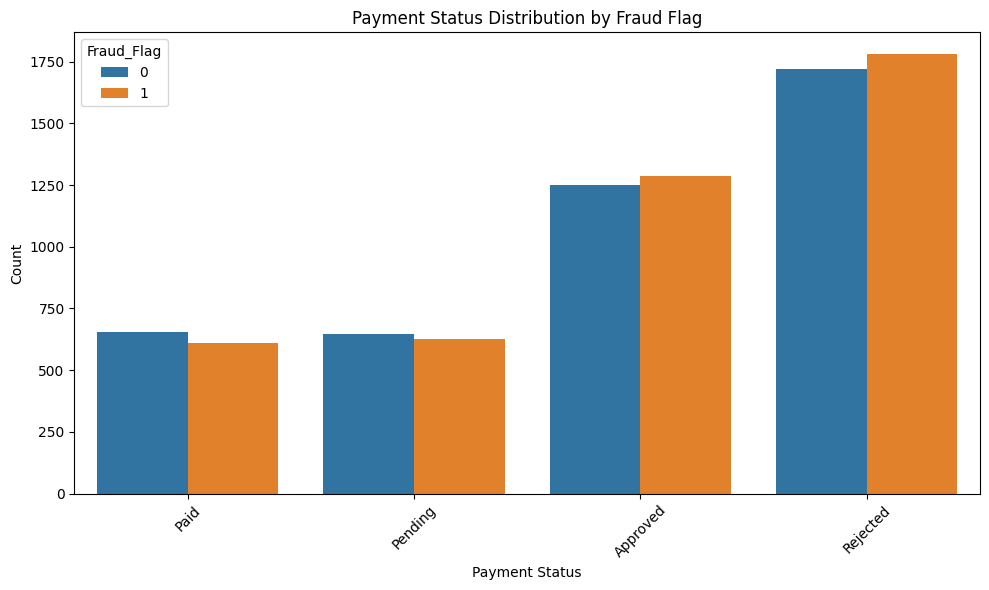

In [20]:
# Reconstruct 'Payment_Status' for plotting as it was one-hot encoded
temp_payment_status = pd.Series(index=df.index, dtype=str)
temp_payment_status[df['Payment_Status_Paid'] == True] = 'Paid'
temp_payment_status[df['Payment_Status_Pending'] == True] = 'Pending'
temp_payment_status[df['Payment_Status_Rejected'] == True] = 'Rejected'
# Assuming 'Approved' was the dropped category because of drop_first=True
# so if all dummy columns are False, the original category was 'Approved'.
temp_payment_status = temp_payment_status.fillna('Approved')

plt.figure(figsize=(10, 6))
sns.countplot(x=temp_payment_status, hue='Fraud_Flag', data=df)
plt.title('Payment Status Distribution by Fraud Flag')
plt.xlabel('Payment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Fraud Flag Distribution (Pie Chart)
Let's visualize the proportion of fraudulent transactions.

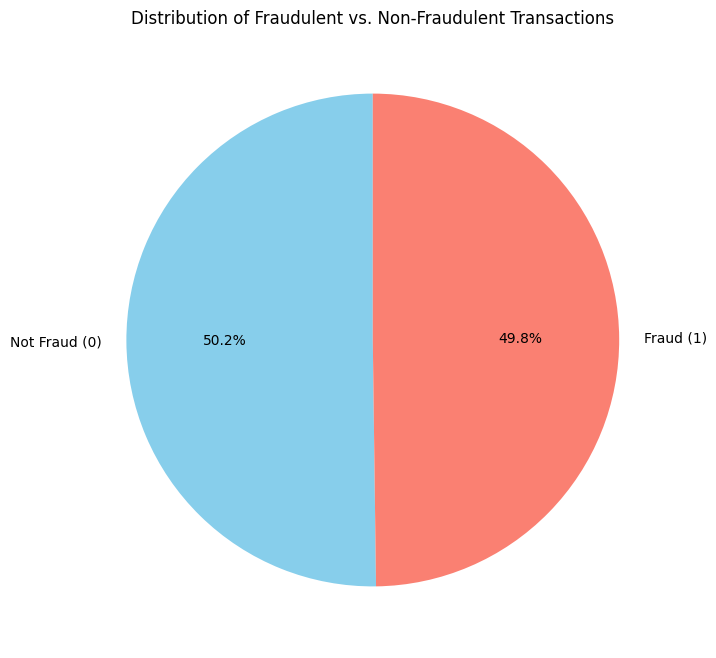

In [21]:
fraud_counts = df['Fraud_Flag'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(fraud_counts, labels=['Not Fraud (0)', 'Fraud (1)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.show()

### Invoice Amount Distribution by Fraud Flag (Box Plot)
This box plot helps to visualize the distribution of invoice amounts for both fraudulent and non-fraudulent transactions, and can reveal potential outliers in each group.

/tmp/ipykernel_4619/1797131376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fraud_Flag', y='Invoice_Amount', data=df, palette=['skyblue', 'salmon'])


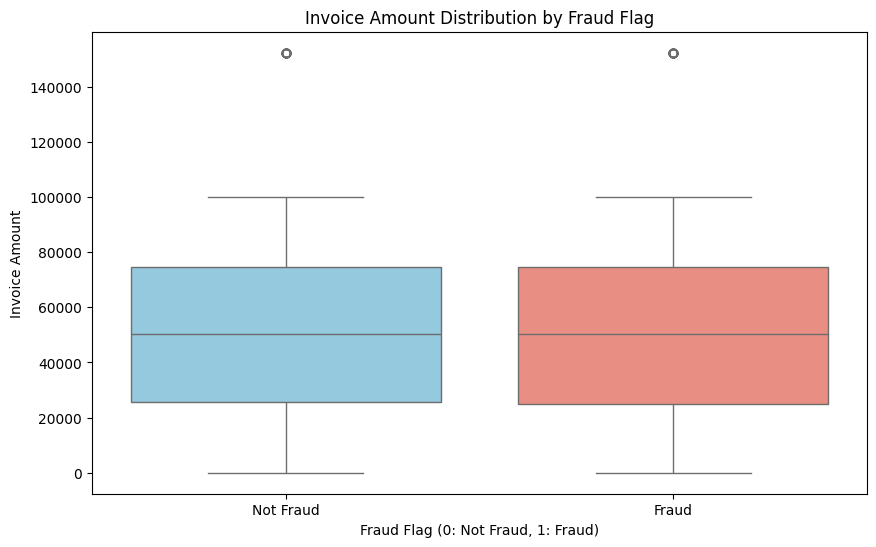

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fraud_Flag', y='Invoice_Amount', data=df, palette=['skyblue', 'salmon'])
plt.title('Invoice Amount Distribution by Fraud Flag')
plt.xlabel('Fraud Flag (0: Not Fraud, 1: Fraud)')
plt.ylabel('Invoice Amount')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

### Credit Period Days Distribution by Fraud Flag (Box Plot)
This plot helps to see if there are differences in the credit period (days between invoice and due date) for fraudulent vs. non-fraudulent transactions, potentially highlighting anomalies related to payment terms.

### Correlation Heatmap

This heatmap visualizes the correlation matrix of all numerical features, including the `Fraud_Flag`, to identify strong positive or negative relationships.

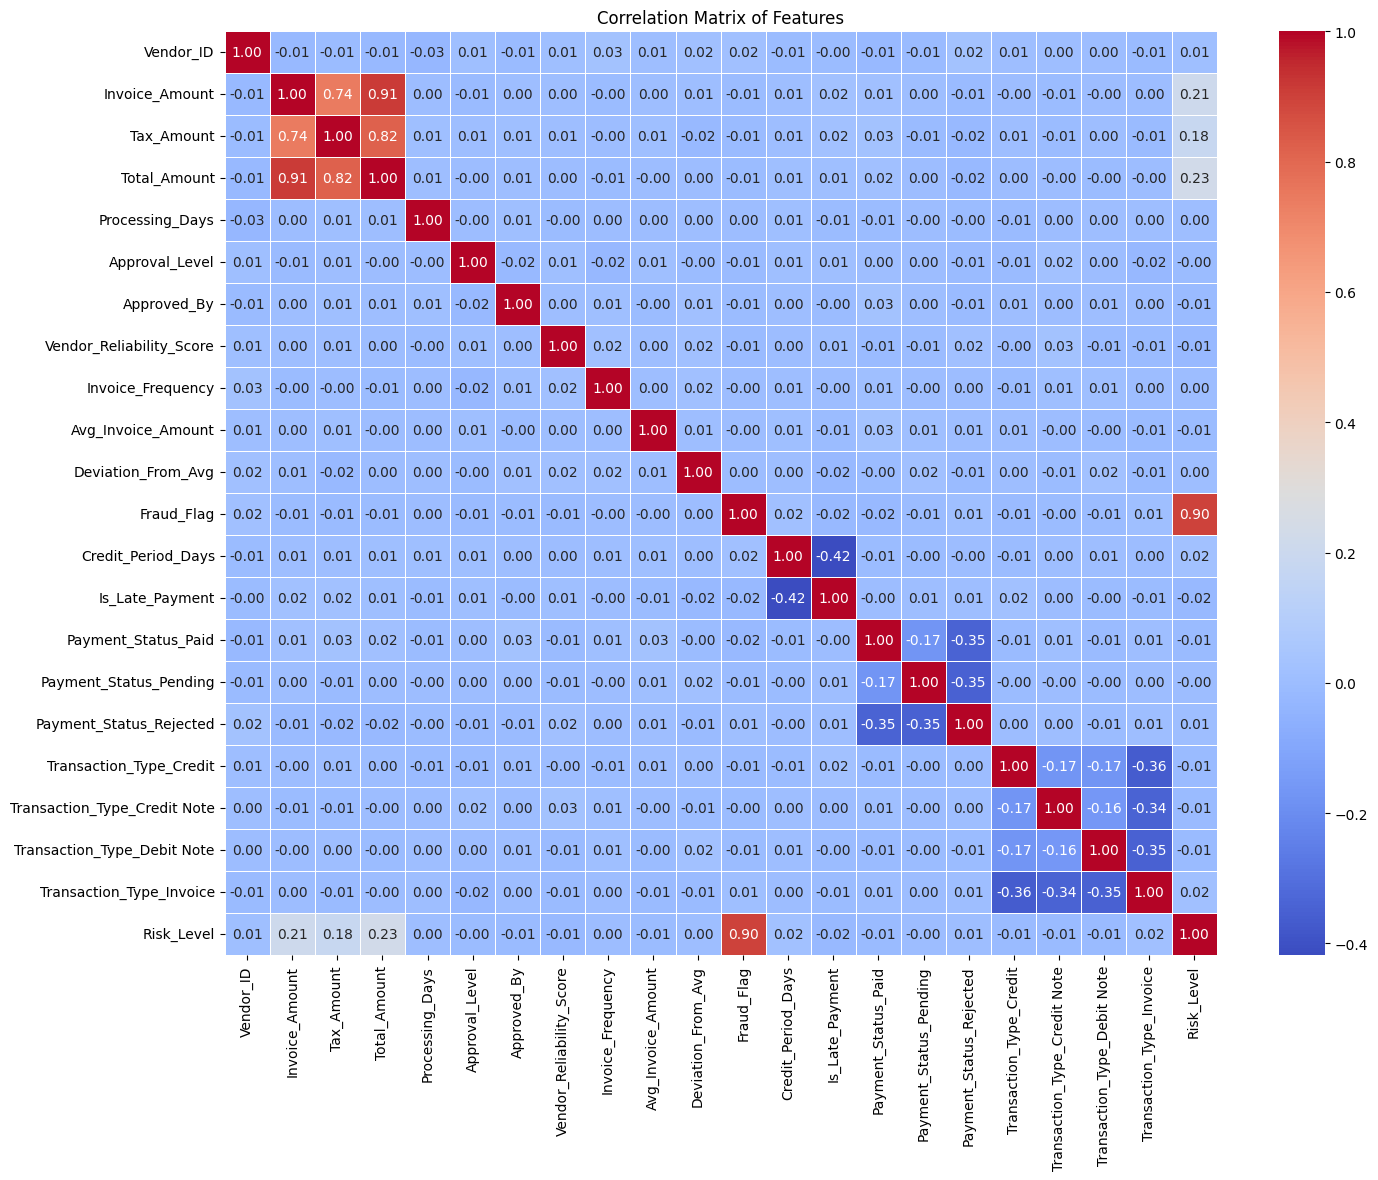

In [23]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

In [24]:
high_risk_count = df[df['Risk_Level'] == 2].shape[0]
print(f"Number of High Risk flagged transactions: {high_risk_count}")

Number of High Risk flagged transactions: 1077


In [25]:
low_risk_count = df[df['Risk_Level'] == 0].shape[0]
medium_risk_count = df[df['Risk_Level'] == 1].shape[0]

print(f"Number of Low Risk flagged transactions: {low_risk_count}")
print(f"Number of Medium Risk flagged transactions: {medium_risk_count}")

Number of Low Risk flagged transactions: 4270
Number of Medium Risk flagged transactions: 3229


### Creating a Binary Risk Flag

To simplify the risk classification, we will create a new binary flag (`Binary_Risk_Flag`) where:
- Low Risk (0) and Medium Risk (1) are grouped as `0` (Lower Risk).
- High Risk (2) is grouped as `1` (Higher Risk).

In [26]:
# Create the new binary risk flag column
# Map Risk_Level 0 and 1 to 0, and Risk_Level 2 to 1
df['Binary_Risk_Flag'] = df['Risk_Level'].apply(lambda x: 1 if x == 2 else 0)

# Display the value counts for the new column to verify the mapping
print("Distribution of Binary_Risk_Flag:")
print(df['Binary_Risk_Flag'].value_counts())

# Display a sample of the DataFrame with original Risk_Level and the new Binary_Risk_Flag
print("\nSample of DataFrame with Risk_Level and Binary_Risk_Flag:")
display(df[['Risk_Level', 'Binary_Risk_Flag']].sample(5))

Distribution of Binary_Risk_Flag:
Binary_Risk_Flag
0    7499
1    1077
Name: count, dtype: int64

Sample of DataFrame with Risk_Level and Binary_Risk_Flag:


,Risk_Level,Binary_Risk_Flag
9307,0,0
9245,1,0
9169,0,0
1665,0,0
8912,0,0


### Saving Updated and Flagged Datasets

Now that we have performed cleaning, feature engineering, and created the `Binary_Risk_Flag`, let's save the full updated dataset and a filtered dataset containing only the high-risk flagged transactions (where `Binary_Risk_Flag == 1`).

In [27]:
# Save the full updated dataset
df.to_csv('final_cleaned_data.csv', index=False)
print("Full updated dataset saved to 'final_cleaned_data.csv'")

# Create a DataFrame for high-risk flagged transactions
high_risk_df = df[df['Binary_Risk_Flag'] == 1].copy()

# Save the high-risk flagged dataset
high_risk_df.to_csv('high_risk_flagged_data.csv', index=False)
print("High-risk flagged dataset saved to 'high_risk_flagged_data.csv'")

print("\nShape of the full updated dataset:", df.shape)
print("Shape of the high-risk flagged dataset:", high_risk_df.shape)

print("\nFirst 5 rows of the high-risk flagged dataset:")
display(high_risk_df.head())

Full updated dataset saved to 'final_cleaned_data.csv'
High-risk flagged dataset saved to 'high_risk_flagged_data.csv'

Shape of the full updated dataset: (8576, 23)
Shape of the high-risk flagged dataset: (1077, 23)

First 5 rows of the high-risk flagged dataset:


,Vendor_ID,Invoice_Amount,Tax_Amount,Total_Amount,Processing_Days,Approval_Level,Approved_By,Vendor_Reliability_Score,Invoice_Frequency,Avg_Invoice_Amount,...,Is_Late_Payment,Payment_Status_Paid,Payment_Status_Pending,Payment_Status_Rejected,Transaction_Type_Credit,Transaction_Type_Credit Note,Transaction_Type_Debit Note,Transaction_Type_Invoice,Risk_Level,Binary_Risk_Flag
3,468,79623.0,10956.54,92393.71,5.0,1,4,1.0,49,20977,...,0,True,False,False,False,False,False,True,2,1
11,873,80592.0,8667.80,87137.78,15.0,5,0,2.0,7,42920,...,1,False,False,True,False,False,False,True,2,1
19,523,96331.0,13384.91,111301.38,17.0,3,0,5.0,46,47994,...,1,False,False,True,False,False,False,False,2,1
22,5,82523.0,9081.75,96289.06,24.0,4,0,7.0,44,7453,...,0,False,False,False,False,True,False,False,2,1
28,2,94370.0,4821.06,104947.07,7.0,4,0,3.0,18,45052,...,0,True,False,False,False,True,False,False,2,1


### Binary Fraud Risk Classification Model Training

Now, let's train machine learning models to predict the `Binary_Risk_Flag` (0: Lower Risk, 1: Higher Risk). We will use Logistic Regression, Random Forest, and XGBoost classifiers.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features (X) and target (y) for binary classification
# Drop 'Fraud_Flag' and 'Risk_Level' as 'Binary_Risk_Flag' is now our primary target
X_binary = df.drop(columns=['Fraud_Flag', 'Risk_Level', 'Binary_Risk_Flag'])
y_binary = df['Binary_Risk_Flag']

# Split the data into training and testing sets (70% train, 30% test)
# Use stratify=y_binary to maintain the proportion of each risk level in train and test sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print(f"X_train_binary shape: {X_train_binary.shape}")
print(f"y_train_binary shape: {y_train_binary.shape}")
print(f"X_test_binary shape: {X_test_binary.shape}")
print(f"y_test_binary shape: {y_test_binary.shape}")

X_train_binary shape: (6003, 20)
y_train_binary shape: (6003,)
X_test_binary shape: (2573, 20)
y_test_binary shape: (2573,)


#### Logistic Regression for Binary Risk Classification

We'll start with Logistic Regression as a baseline model to predict `Binary_Risk_Flag`.


Logistic Regression (Binary Risk Flag) Classification Report:
                 precision    recall  f1-score   support

 Lower Risk (0)       0.98      0.74      0.84      2250
Higher Risk (1)       0.33      0.87      0.48       323

       accuracy                           0.76      2573
      macro avg       0.65      0.81      0.66      2573
   weighted avg       0.89      0.76      0.80      2573



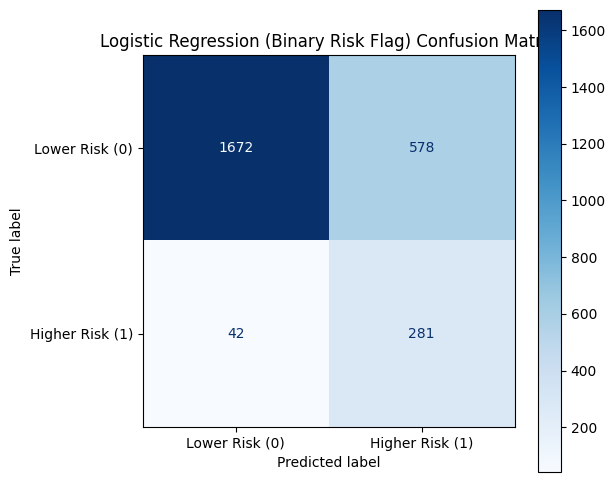

In [29]:
# Initialize and train the Logistic Regression model for binary classification
lr_model_binary = LogisticRegression(
    solver='liblinear', # 'liblinear' works well for small datasets and binary classification
    random_state=42,
    max_iter=1000,
    class_weight='balanced' # To handle potential class imbalance
)
lr_model_binary.fit(X_train_binary, y_train_binary)

# Make predictions on the test set
y_pred_lr_binary = lr_model_binary.predict(X_test_binary)

# Evaluate the model
print("\nLogistic Regression (Binary Risk Flag) Classification Report:")
print(classification_report(y_test_binary, y_pred_lr_binary, target_names=['Lower Risk (0)', 'Higher Risk (1)']))

# Display the confusion matrix
cm_lr_binary = confusion_matrix(y_test_binary, y_pred_lr_binary, labels=lr_model_binary.classes_)
disp_lr_binary = ConfusionMatrixDisplay(confusion_matrix=cm_lr_binary, display_labels=['Lower Risk (0)', 'Higher Risk (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_lr_binary.plot(cmap='Blues', ax=ax)
ax.set_title('Logistic Regression (Binary Risk Flag) Confusion Matrix')
plt.show()

#### Random Forest Classifier for Binary Risk Classification

Next, let's try a Random Forest Classifier, which is generally more robust for complex datasets.


RandomForestClassifier (Binary Risk Flag) Classification Report:
                 precision    recall  f1-score   support

 Lower Risk (0)       0.89      0.97      0.93      2250
Higher Risk (1)       0.47      0.21      0.29       323

       accuracy                           0.87      2573
      macro avg       0.68      0.59      0.61      2573
   weighted avg       0.84      0.87      0.85      2573



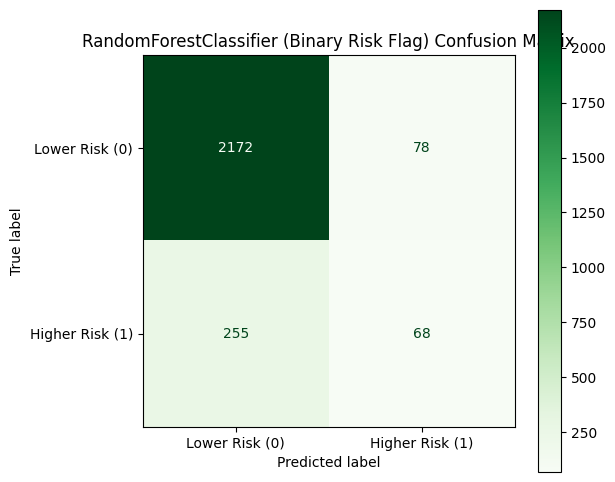

In [30]:
# Initialize and train the RandomForestClassifier for binary classification
rf_model_binary = RandomForestClassifier(
    random_state=42,
    n_estimators=200, # Increased estimators for better performance
    class_weight='balanced' # To handle potential class imbalance
)
rf_model_binary.fit(X_train_binary, y_train_binary)

# Make predictions on the test set
y_pred_rf_binary = rf_model_binary.predict(X_test_binary)

# Evaluate the model
print("\nRandomForestClassifier (Binary Risk Flag) Classification Report:")
print(classification_report(y_test_binary, y_pred_rf_binary, target_names=['Lower Risk (0)', 'Higher Risk (1)']))

# Display the confusion matrix
cm_rf_binary = confusion_matrix(y_test_binary, y_pred_rf_binary, labels=rf_model_binary.classes_)
disp_rf_binary = ConfusionMatrixDisplay(confusion_matrix=cm_rf_binary, display_labels=['Lower Risk (0)', 'Higher Risk (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf_binary.plot(cmap='Greens', ax=ax)
ax.set_title('RandomForestClassifier (Binary Risk Flag) Confusion Matrix')
plt.show()

#### XGBoost Classifier for Binary Risk Classification

Finally, we'll apply an XGBoost Classifier, known for its strong performance in classification tasks.


XGBoost Classifier (Binary Risk Flag) Classification Report:
                 precision    recall  f1-score   support

 Lower Risk (0)       0.96      0.89      0.93      2250
Higher Risk (1)       0.51      0.76      0.61       323

       accuracy                           0.88      2573
      macro avg       0.73      0.83      0.77      2573
   weighted avg       0.91      0.88      0.89      2573



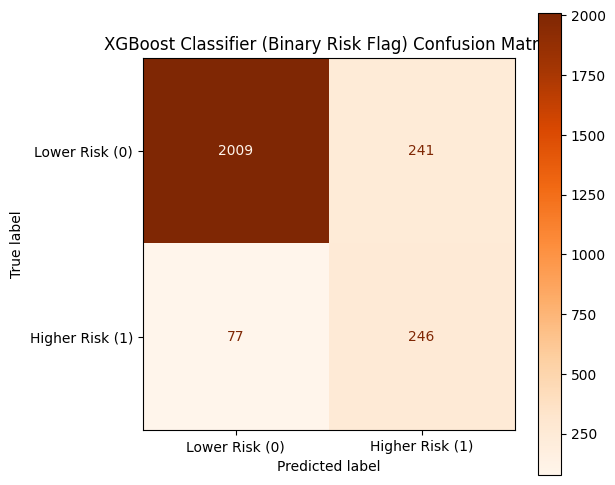

In [31]:
# Initialize and train the XGBoost Classifier for binary classification
xgb_model_binary = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss', # Metric for binary classification
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    scale_pos_weight=(y_train_binary == 0).sum() / (y_train_binary == 1).sum() # Handle class imbalance
)
xgb_model_binary.fit(X_train_binary, y_train_binary)

# Make predictions on the test set
y_pred_xgb_binary = xgb_model_binary.predict(X_test_binary)

# Evaluate the model
print("\nXGBoost Classifier (Binary Risk Flag) Classification Report:")
print(classification_report(y_test_binary, y_pred_xgb_binary, target_names=['Lower Risk (0)', 'Higher Risk (1)'])
)

# Display the confusion matrix
cm_xgb_binary = confusion_matrix(y_test_binary, y_pred_xgb_binary, labels=xgb_model_binary.classes_)
disp_xgb_binary = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_binary, display_labels=['Lower Risk (0)', 'Higher Risk (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb_binary.plot(cmap='Oranges', ax=ax)
ax.set_title('XGBoost Classifier (Binary Risk Flag) Confusion Matrix')
plt.show()

In [32]:
import pandas as pd

# 'model' was not defined. Using xgb_model_binary, which was trained earlier.
# 'X_test' should be 'X_test_binary' and 'y_test' should be 'y_test_binary'.
probabilities = xgb_model_binary.predict_proba(X_test_binary)[:, 1]

# NOTE: The 'Invoice_ID' column was dropped from 'df' in an earlier step (cell HRa0gdFZSlk2).
# To include 'Invoice_ID' in the report, you would need to have retained it
# before dropping it from 'df' or from X_binary. For example, if you had an 'original_df'
# that still contained 'Invoice_ID', you could use: original_df.loc[X_test_binary.index, 'Invoice_ID']
# For now, we will create the report without 'Invoice_ID' to fix the current error.
# If you need 'Invoice_ID', you will need to re-evaluate the data preparation steps.
risk_report = pd.DataFrame({
    # 'Invoice_ID': df.loc[X_test_binary.index, 'Invoice_ID'], # This line will cause a KeyError if Invoice_ID is not present
    'Actual_Flag': y_test_binary,
    'Fraud_Probability': probabilities
})

def assign_risk_level(prob):
    if prob > 0.9:
        return 'Critical'
    elif prob > 0.7:
        return 'High'
    elif prob > 0.5:
        return 'Medium'
    else:
        return 'Low'

risk_report['Risk_Level'] = risk_report['Fraud_Probability'].apply(assign_risk_level)

risk_report = risk_report.sort_values(by='Fraud_Probability', ascending=False)

print(risk_report.head(20))

risk_report.to_csv('audit_priority_list.csv', index=False)

      Actual_Flag  Fraud_Probability Risk_Level
9056            0           0.991517   Critical
1067            1           0.990083   Critical
2290            0           0.988694   Critical
3270            1           0.987432   Critical
4660            1           0.985341   Critical
6929            0           0.985053   Critical
5911            0           0.984492   Critical
7919            1           0.983905   Critical
3667            1           0.983094   Critical
1242            1           0.982998   Critical
5729            0           0.981519   Critical
2910            0           0.981112   Critical
6321            1           0.980445   Critical
7955            0           0.978749   Critical
6585            0           0.976416   Critical
4923            1           0.975826   Critical
8722            0           0.975097   Critical
8741            1           0.973654   Critical
2183            1           0.973338   Critical
9864            1           0.969972   C

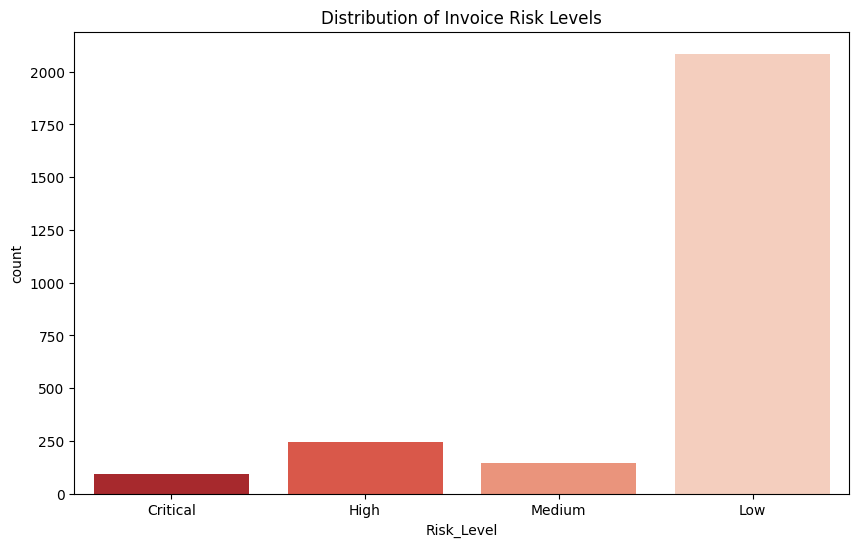

<Figure size 1000x800 with 0 Axes>

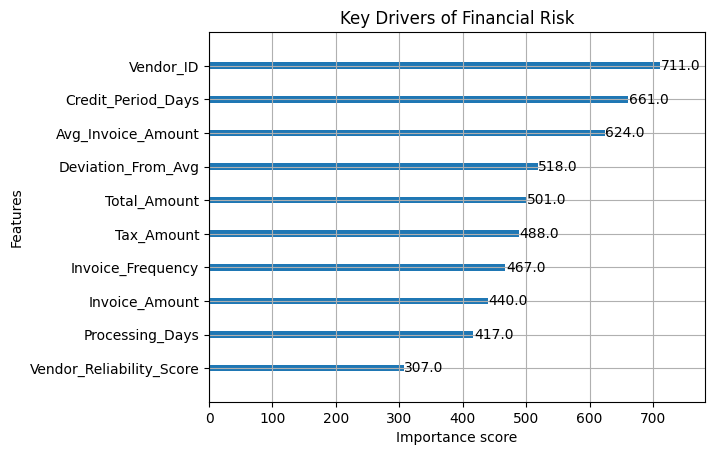

Total Critical Invoices identified: 94
Total High Risk Invoices identified: 246


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(x='Risk_Level', data=risk_report, order=['Critical', 'High', 'Medium', 'Low'], palette='Reds_r', hue='Risk_Level', legend=False)
plt.title('Distribution of Invoice Risk Levels')
plt.show()

import xgboost as xgb
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model_binary, max_num_features=10, importance_type='weight')
plt.title('Key Drivers of Financial Risk')
plt.show()

print(f"Total Critical Invoices identified: {len(risk_report[risk_report['Risk_Level'] == 'Critical'])}")
print(f"Total High Risk Invoices identified: {len(risk_report[risk_report['Risk_Level'] == 'High'])}")

### Invoice Anomaly Detection Model

Given the modest performance of previous classification models, let's explore anomaly detection as an alternative approach to identify potentially fraudulent invoices. We will use the Isolation Forest algorithm, which is well-suited for high-dimensional datasets and works by isolating observations instead of profiling normal points.

In [34]:
from sklearn.ensemble import IsolationForest

# The Isolation Forest model is typically unsupervised, so we'll use our features (X_binary)
# For anomaly detection, we often assume that the 'normal' class is much larger than the 'anomalous' class.
# The 'contamination' parameter is the proportion of outliers in the dataset.
# We can estimate it based on the proportion of 'Higher Risk' transactions (Binary_Risk_Flag == 1).

contamination_rate = y_binary.value_counts(normalize=True)[1]
print(f"Estimated contamination rate (proportion of Higher Risk transactions): {contamination_rate:.4f}")

# Initialize and train the Isolation Forest model
# n_estimators: The number of base estimators (trees) in the ensemble.
# max_features: The number of features to draw from X to train each base estimator.
# random_state: For reproducibility.
# contamination: The amount of contamination of the dataset, i.e. the proportion of outliers in the dataset.

iso_forest_model = IsolationForest(
    n_estimators=100,
    max_features=1.0,
    contamination=contamination_rate, # Use the estimated contamination rate
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# Fit the model to the training data (no need for y_train, as it's unsupervised)
iso_forest_model.fit(X_binary)

print("Isolation Forest model trained successfully.")

Estimated contamination rate (proportion of Higher Risk transactions): 0.1256
Isolation Forest model trained successfully.


### Anomaly Prediction and Analysis

After training the Isolation Forest model, we can predict anomaly scores and labels for each transaction. A lower score indicates a higher likelihood of being an anomaly.


Distribution of Anomaly Labels:
is_anomaly
0    7499
1    1077
Name: count, dtype: int64

Sample of DataFrame with Anomaly Scores and Labels:


,Total_Amount,Binary_Risk_Flag,anomaly_score,is_anomaly
7619,67169.77,0,0.061795,0
9788,99986.82,1,0.026406,0
632,35436.74,0,0.027262,0
8393,22062.63,0,0.047707,0
4662,16959.69,0,0.012776,0
2578,18877.38,0,0.071642,0
8310,94583.98,1,0.002295,0
2602,8253.61,0,-0.021365,1
4501,106405.78,1,0.011876,0
2472,34280.72,0,0.012000,0


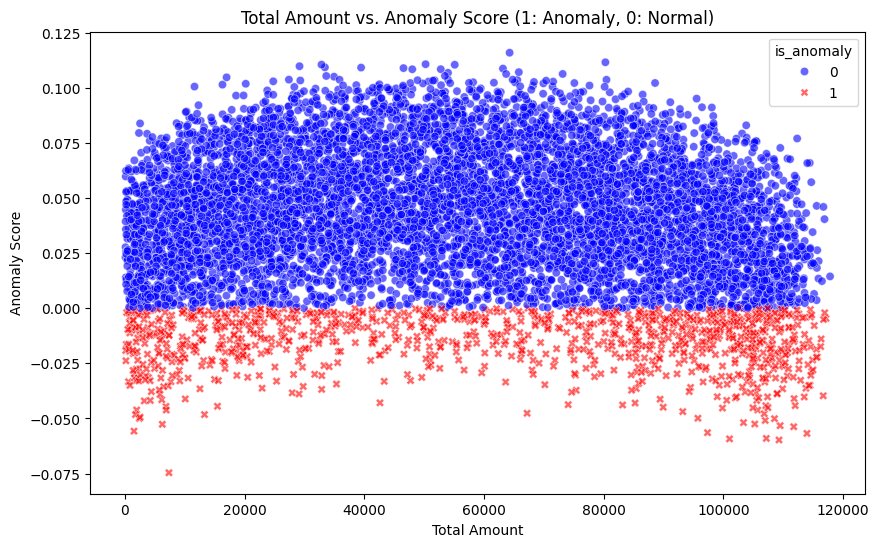


Cross-tabulation of Binary_Risk_Flag and is_anomaly:


is_anomaly,0,1
Binary_Risk_Flag,,
0,6635,864
1,864,213


In [35]:
# Predict anomaly scores (the lower, the more abnormal) and anomaly labels (-1 for outliers, 1 for inliers)
df['anomaly_score'] = iso_forest_model.decision_function(X_binary)
df['anomaly_label'] = iso_forest_model.predict(X_binary)

# Convert anomaly labels to a more intuitive format: 1 for anomaly, 0 for normal
df['is_anomaly'] = df['anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

# Display the distribution of anomaly labels
print("\nDistribution of Anomaly Labels:")
print(df['is_anomaly'].value_counts())

# Display the first few rows with anomaly scores and labels
print("\nSample of DataFrame with Anomaly Scores and Labels:")
display(df[['Total_Amount', 'Binary_Risk_Flag', 'anomaly_score', 'is_anomaly']].sample(10))

# Visualize the relationship between Total_Amount and anomaly score for anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Amount',
    y='anomaly_score',
    hue='is_anomaly',
    style='is_anomaly',
    palette=['blue', 'red'],
    data=df,
    alpha=0.6
)
plt.title('Total Amount vs. Anomaly Score (1: Anomaly, 0: Normal)')
plt.xlabel('Total Amount')
plt.ylabel('Anomaly Score')
plt.show()

# Let's compare the 'is_anomaly' flag with our 'Binary_Risk_Flag'
print("\nCross-tabulation of Binary_Risk_Flag and is_anomaly:")
display(pd.crosstab(df['Binary_Risk_Flag'], df['is_anomaly']))

### Distribution of Anomaly Flags (Pie Chart)

Let's visualize the proportion of transactions identified as anomalies by the Isolation Forest model.

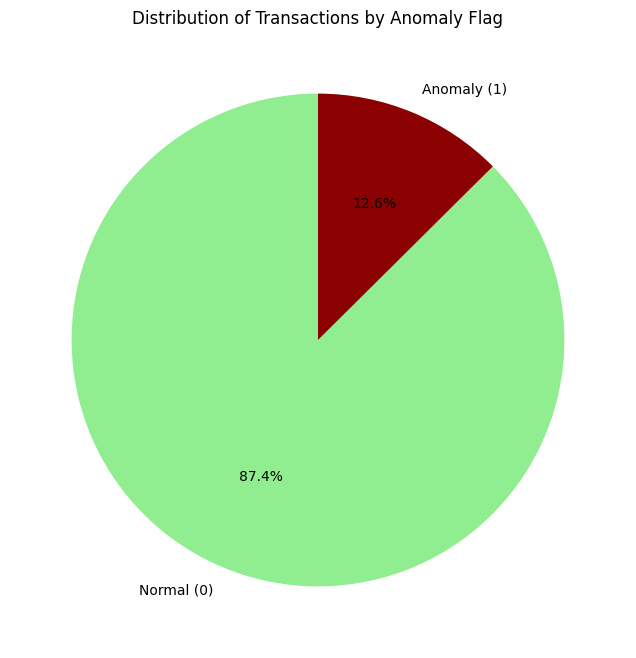

In [36]:
anomaly_counts = df['is_anomaly'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    anomaly_counts,
    labels=['Normal (0)', 'Anomaly (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'darkred']
)
plt.title('Distribution of Transactions by Anomaly Flag')
plt.show()

### Vendor Reliability Score vs. Anomaly Status

Let's investigate if there's a noticeable difference in `Vendor_Reliability_Score` for transactions flagged as anomalies versus those considered normal. This could indicate whether unreliable vendors are more often associated with anomalous activities.

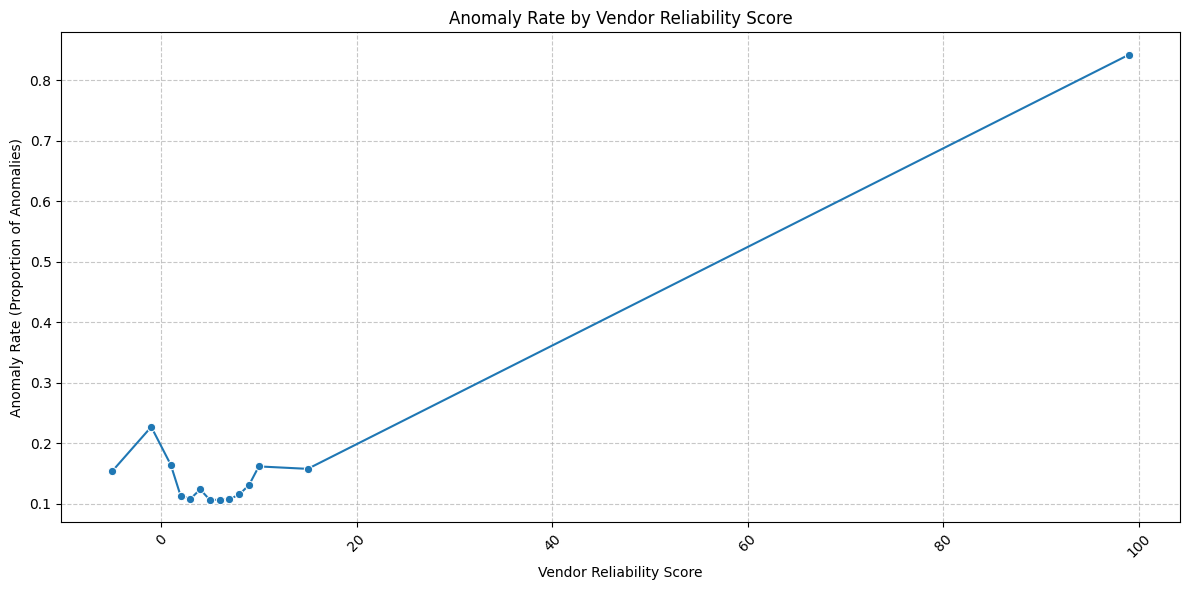

In [37]:
anomaly_rate_by_vendor_score = df.groupby('Vendor_Reliability_Score')['is_anomaly'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Vendor_Reliability_Score', y='is_anomaly', data=anomaly_rate_by_vendor_score, marker='o')
plt.title('Anomaly Rate by Vendor Reliability Score')
plt.xlabel('Vendor Reliability Score')
plt.ylabel('Anomaly Rate (Proportion of Anomalies)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
import joblib

# Save the best performing binary classification model
joblib.dump(xgb_model_binary, 'xgb_binary_risk_model.joblib')
print("XGBoost binary risk model saved as 'xgb_binary_risk_model.joblib'")

XGBoost binary risk model saved as 'xgb_binary_risk_model.joblib'


### Pushing the Saved Model to GitHub with Git LFS

To push your `xgb_binary_risk_model.joblib` to GitHub, especially if it's a large file, it's recommended to use Git Large File Storage (Git LFS).

**1. Install Git LFS (if you haven't already):**

First, you need to install Git LFS on your system (e.g., your local machine or if you want to use it directly in Colab's terminal):

```bash
sudo apt-get update
sudo apt-get install git-lfs
git lfs install
```

**2. Track your model file with Git LFS:**

Navigate to your project directory (e.g., `/content/` in Colab) and tell Git LFS to track your `.joblib` files. This command should be run once per file type you want to track:

```bash
git lfs track "*.joblib"
```

**3. Add your model file and `.gitattributes` to Git:**

The `git lfs track` command creates or updates a `.gitattributes` file. You need to add both this file and your model file to your Git staging area:

```bash
git add .gitattributes
git add xgb_binary_risk_model.joblib
```

**4. Commit your changes:**

Commit the changes to your local repository:

```bash
git commit -m "Add XGBoost binary risk model with Git LFS"
```

**5. Configure your GitHub repository (if not already done):**

If you haven't already, link your local repository to a remote GitHub repository. Replace `YOUR_USERNAME` and `YOUR_REPOSITORY` with your actual GitHub username and repository name.

```bash
git remote add origin https://github.com/YOUR_USERNAME/YOUR_REPOSITORY.git
# Or if the remote already exists, you can set the URL:
# git remote set-url origin https://github.com/YOUR_USERNAME/YOUR_REPOSITORY.git
```

**6. Push to GitHub:**

Finally, push your committed changes (including the LFS pointer for your model file) to GitHub:

```bash
git push origin main # or 'master', depending on your branch name
```

**Note:** When working in Google Colab, you would typically execute these commands in the Colab terminal (`Ctrl+Shift+T` or from `Terminal` menu).
